In [25]:
from google.colab import files
uploaded = files.upload()

Saving test_set.zip to test_set (1).zip


In [ ]:
import zipfile

with zipfile.ZipFile('/content/test_set.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [ ]:
import os

print(os.listdir('/content'))

In [ ]:
print(os.listdir('/content/test_set'))

In [ ]:
import os
import cv2
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import shuffle

In [ ]:
import os

print(os.listdir('/content'))
print(os.listdir('/content/test_set'))

In [ ]:
print(os.listdir('/content/test_set'))

In [ ]:
import os
import cv2
import numpy as np

data = []
labels = []

IMG_SIZE = 64

DATADIR = "/content/test_set"
categories = ["cats", "dogs"]

for category in categories:

    path = os.path.join(DATADIR, category)

    label = categories.index(category)

    count = 0

    for img in os.listdir(path):

        try:
            img_path = os.path.join(path, img)

            image = cv2.imread(img_path)

            if image is not None:

                image = cv2.resize(image, (64,64))

                data.append(image)
                labels.append(label)

                count += 1

                if count == 500:
                    break

        except:
            pass

print("Images Loaded :", len(data))

In [ ]:
X = np.array(data)
y = np.array(labels)

print(X.shape)
print(np.unique(y))

In [ ]:
from sklearn.utils import shuffle

X, y = shuffle(X, y, random_state=42)

X = X.reshape(len(X), -1)

X = X / 255.0

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
print(np.unique(y_train))
print(np.unique(y_test))

[0 1]
[0 1]


In [26]:
from sklearn.svm import SVC

model = SVC(kernel='linear')

model.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy :", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

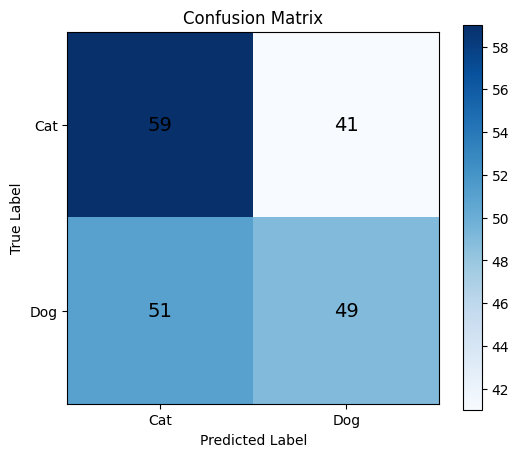

In [28]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

plt.imshow(cm, cmap='Blues')
plt.colorbar()

plt.xticks([0,1], ['Cat','Dog'])
plt.yticks([0,1], ['Cat','Dog'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center',
                 fontsize=14)

plt.show()